# Binary Classification with CNNs: pneumonia_MNIST Data Set

## Setup

In [1]:
import numpy as np
import tensorflow as tf


import datetime

notebook_start_time = datetime.datetime.now()

I0000 00:00:1782545089.820572  137597 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782545090.634148  137597 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
test_dir = "data/test"
train_dir = "data/train"
validation_dir = "data/val"

height, width, channels = 150, 150, 1

batch_size = 32

# While working, I discovered that the tf.keras.preprocessing.image.ImageDataGenerator class is deprecated
# using this new API instead

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="grayscale",
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="grayscale",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="grayscale",
    shuffle=False,
)

# because the outputs are batched, we have to concatenate all the batches
y_true = np.concatenate([y for x, y in test_ds], axis=0)

Found 4442 files belonging to 2 classes.
Found 790 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [3]:
from visualization import reset_keras, summary_graphics

In [4]:
def get_class_training_weights(assignments, normalize=True):
    # inverse-frequency weighting: up-weight the MINORITY class
    n_total = len(assignments)
    n_pos = float(sum(assignments))  # number of class-1 (pneumonia) labels
    n_neg = n_total - n_pos  # number of class-0 (normal) labels
    weight_0 = n_total / (2 * n_neg)
    weight_1 = n_total / (2 * n_pos)
    if normalize:
        denom = max(weight_0, weight_1)
        weight_0 = weight_0 / denom
        weight_1 = weight_1 / denom
    return {0: weight_0, 1: weight_1}


class_weight = get_class_training_weights(tf.concat([y for x, y in train_ds], axis=0))

print(f"Weight for normal class: {class_weight[0]:1.3f}")
print(f"Weight for pneumonia class: {class_weight[1]:1.3f}")

Weight for normal class: 1.000
Weight for pneumonia class: 0.348


## Training

In [5]:
reset_keras()

epochs = 10
model_1 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="resizing"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(1000, activation="relu", name="5.2dense"),
        tf.keras.layers.Dense(500, activation="relu", name="5.4dense"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_1",
)

metrics = [
    tf.keras.metrics.TruePositives(name="tp"),
    tf.keras.metrics.TrueNegatives(name="tn"),
    tf.keras.metrics.BinaryAccuracy(name="accuracy"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
]

model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)


def make_callbacks(filepath):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=filepath, save_best_only=True, monitor="val_loss", mode="min"
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", mode="min", patience=5, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", mode="min", factor=0.5, patience=3
        ),
    ]


model_1.summary()

Model: "Model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.1flatten (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.2dense (Dense)                │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.4dense (Dense)                │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286,001 (4.91 MB)

 Trainable params: 1,286,001 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model_1.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks("best_model_resizing_dense.keras"),
)

Epoch 1/10


/home/sam/Documents/projects/ConvolutedComputerVision/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.8523 - loss: 2.0587 - precision: 0.9433 - recall: 0.8522 - tn: 977.0000 - tp: 2809.0000 - val_accuracy: 0.8899 - val_loss: 2.1376 - val_precision: 0.8743 - val_recall: 0.9949 - val_tn: 119.0000 - val_tp: 584.0000 - learning_rate: 1.0000e-04
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.8814 - loss: 1.1949 - precision: 0.9547 - recall: 0.8820 - tn: 1008.0000 - tp: 2907.0000 - val_accuracy: 0.9215 - val_loss: 1.7915 - val_precision: 0.9870 - val_recall: 0.9063 - val_tn: 196.0000 - val_tp: 532.0000 - learning_rate: 1.0000e-04
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.9057 - loss: 1.0375 - precision: 0.9663 - recall: 0.9044 - tn: 1042.0000 - tp: 2981.0000 - val_accuracy: 0.9114 - val_loss: 1.6820 - val_precision: 0.9924 - val_recall: 0.8876 - val_tn: 199.0000 - val_tp: 521.0000 - learning_rate: 1.0000e-04
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9309 - loss: 0.547

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


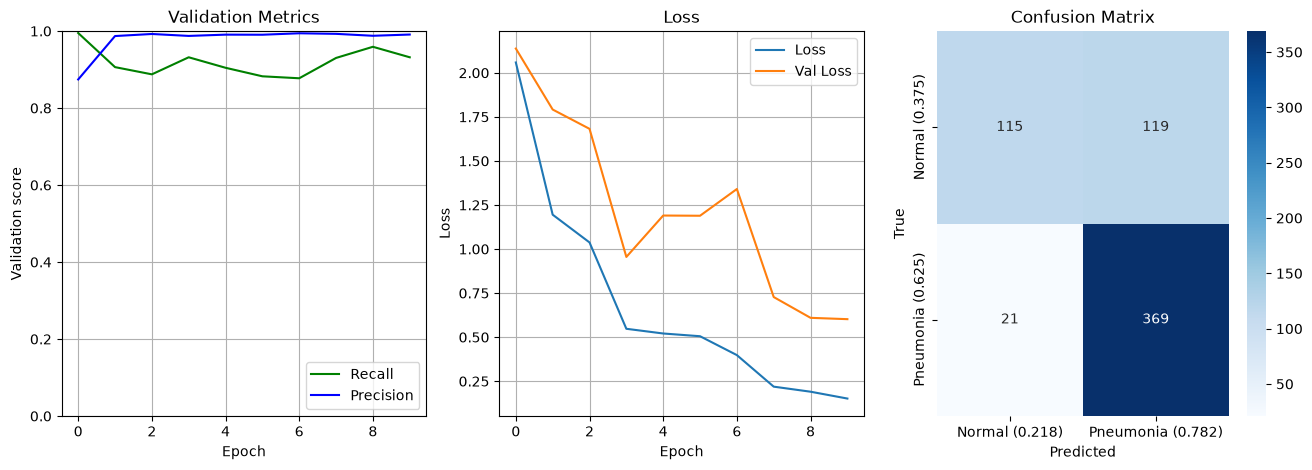

In [7]:
summary_graphics(history, model_1, test_ds)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


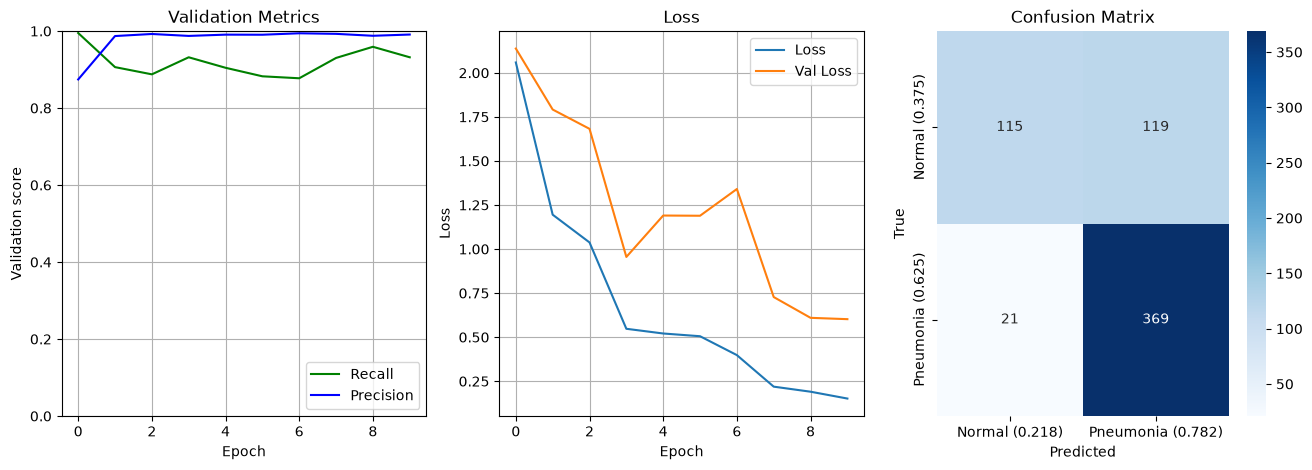

In [8]:
# load the best model
best_model = tf.keras.models.load_model("best_model_resizing_dense.keras")
summary_graphics(history, best_model, test_ds)

In [9]:
reset_keras()

# try something similar to xception, but with fewer filters and layers
# to account for how small these images are
model_2 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="resizing"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(512, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.7, name="5.3dropout"),
        tf.keras.layers.Dense(256, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.5, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_2",
)

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

model_2.summary()

Model: "Model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 0.2rrot (RandomRotation)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 0.3rtran (RandomTranslation)    │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.1conv (Conv2D)                │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.2conv (Conv2D)                │ (None, 28, 28, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.3pool (MaxPooling2D)          │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.1conv (Conv2D)                │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.2conv (Conv2D)                │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.3pool (MaxPooling2D)          │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.1conv (SeparableConv2D)       │ (None, 7, 7, 64)       │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.2batchnorm                    │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.3conv (SeparableConv2D)       │ (None, 7, 7, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.4pool (MaxPooling2D)          │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.1conv (SeparableConv2D)       │ (None, 4, 4, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.2batchnorm                    │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.3conv (SeparableConv2D)       │ (None, 4, 4, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.6pool (MaxPooling2D)          │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.1flatten (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.2dense (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.3dropout (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.4dense (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.5dropout (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           25

 Total params: 296,657 (1.13 MB)

 Trainable params: 296,401 (1.13 MB)

 Non-trainable params: 256 (1.00 KB)

In [10]:
history = model_2.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks("best_model_resizing_2.keras"),
)

Epoch 1/10


/home/sam/Documents/projects/ConvolutedComputerVision/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.6095 - loss: 0.3538 - precision: 0.8707 - recall: 0.5565 - tn: 1028.0000 - tp: 2161.0000 - val_accuracy: 0.7430 - val_loss: 0.6865 - val_precision: 0.7430 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 587.0000 - learning_rate: 1.0000e-04
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.7533 - loss: 0.2479 - precision: 0.9307 - recall: 0.7212 - tn: 969.0000 - tp: 2377.0000 - val_accuracy: 0.7430 - val_loss: 0.6164 - val_precision: 0.7430 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 587.0000 - learning_rate: 1.0000e-04
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.7915 - loss: 0.2199 - precision: 0.9395 - recall: 0.7685 - tn: 983.0000 - tp: 2533.0000 - val_accuracy: 0.8228 - val_loss: 0.5409 - val_precision: 0.8188 - val_recall: 0.9779 - val_tn: 76.0000 - val_tp: 574.0000 - learning_rate: 1.0000e-04
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.7965 - loss: 0.

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


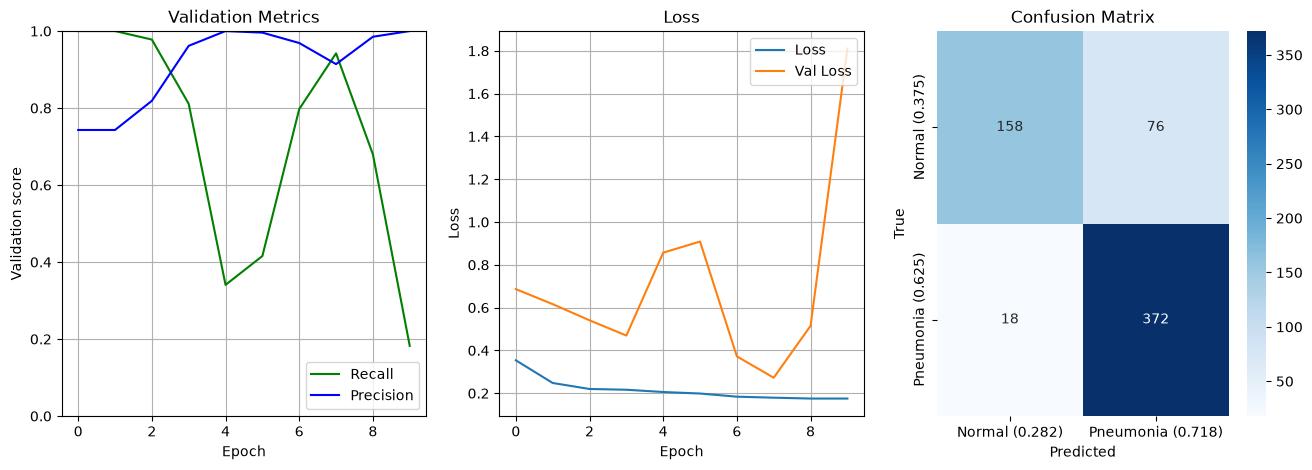

In [11]:
summary_graphics(history, model_2, test_ds)

In [12]:
reset_keras()

# unlike with the MNIST dataset, this model is not overfitting
# let's up the number of neurons
model_3 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="resizing"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            64, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            64, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            256, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            256, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(512, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.5, name="5.3dropout"),
        tf.keras.layers.Dense(256, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.4, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_3",
)

model_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

In [13]:
history = model_3.fit(
    train_ds,
    validation_data=validation_ds,
    batch_size=batch_size,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks("best_model_resizing_3.keras"),
)

Epoch 1/10


/home/sam/Documents/projects/ConvolutedComputerVision/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


139/139 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.6726 - loss: 0.3249 - precision: 0.8288 - recall: 0.7044 - tn: 784.0000 - tp: 2735.0000 - val_accuracy: 0.7430 - val_loss: 0.6342 - val_precision: 0.7430 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 587.0000 - learning_rate: 1.0000e-04
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.7600 - loss: 0.2323 - precision: 0.9295 - recall: 0.7321 - tn: 963.0000 - tp: 2413.0000 - val_accuracy: 0.7430 - val_loss: 0.5880 - val_precision: 0.7430 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 587.0000 - learning_rate: 1.0000e-04
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.7868 - loss: 0.2194 - precision: 0.9417 - recall: 0.7597 - tn: 991.0000 - tp: 2504.0000 - val_accuracy: 0.8380 - val_loss: 0.5227 - val_precision: 0.8390 - val_recall: 0.9676 - val_tn: 94.0000 - val_tp: 568.0000 - learning_rate: 1.0000e-04
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.7972 - loss: 0.2

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


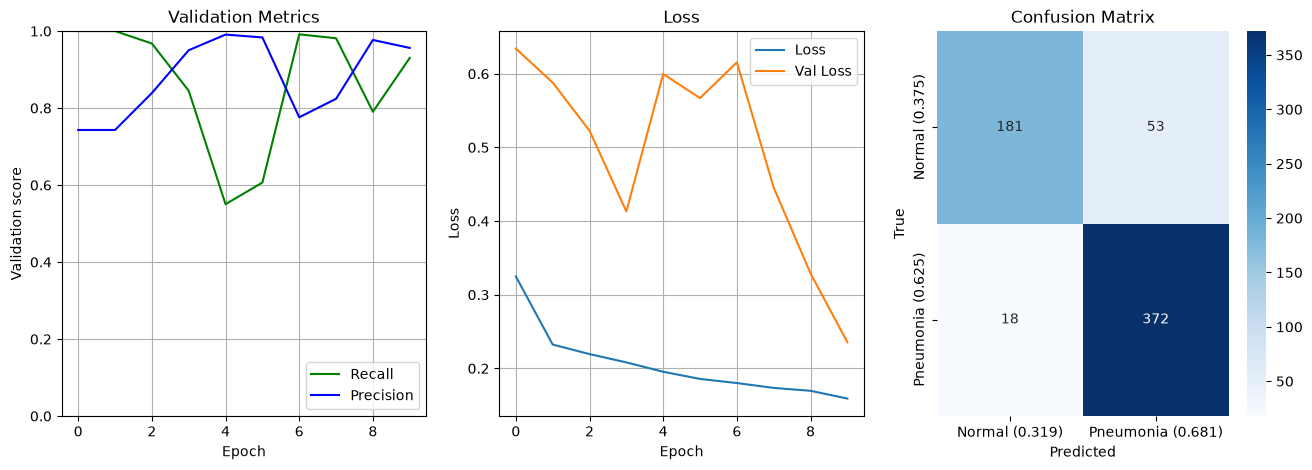

In [14]:
summary_graphics(history, model_3, test_ds)

In [15]:
reset_keras()

# let's increase dropout, add more batch normalization, and add more epochs
epochs = 20
model_4 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="resizing"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="1.2batchnorm"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="1.3conv"
        ),
        tf.keras.layers.BatchNormalization(name="1.4batchnorm"),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            64, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="2.2batchnorm"),
        tf.keras.layers.Conv2D(
            64, (3, 3), activation="relu", padding="same", name="2.3conv"
        ),
        tf.keras.layers.BatchNormalization(name="2.4batchnorm"),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.5pool"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.4batchnorm"),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.5pool"),
        tf.keras.layers.SeparableConv2D(
            256, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            256, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.4batchnorm"),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.5pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(512, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.7, name="5.3dropout"),
        tf.keras.layers.Dense(256, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.5, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_4",
)

model_4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

In [16]:
history = model_4.fit(
    train_ds,
    validation_data=validation_ds,
    batch_size=batch_size,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks("best_model_resizing_4.keras"),
)

Epoch 1/20


/home/sam/Documents/projects/ConvolutedComputerVision/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


139/139 ━━━━━━━━━━━━━━━━━━━━ 25s 142ms/step - accuracy: 0.6422 - loss: 0.4594 - precision: 0.8360 - recall: 0.6443 - tn: 858.0000 - tp: 2502.0000 - val_accuracy: 0.7430 - val_loss: 0.6847 - val_precision: 0.7430 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 587.0000 - learning_rate: 1.0000e-04
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 17s 117ms/step - accuracy: 0.7172 - loss: 0.3048 - precision: 0.8843 - recall: 0.7121 - tn: 839.0000 - tp: 2347.0000 - val_accuracy: 0.7430 - val_loss: 0.6261 - val_precision: 0.7430 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 587.0000 - learning_rate: 1.0000e-04
Epoch 3/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.7681 - loss: 0.2528 - precision: 0.9052 - recall: 0.7679 - tn: 881.0000 - tp: 2531.0000 - val_accuracy: 0.7430 - val_loss: 0.5839 - val_precision: 0.7430 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 587.0000 - learning_rate: 1.0000e-04
Epoch 4/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.7848 - l

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


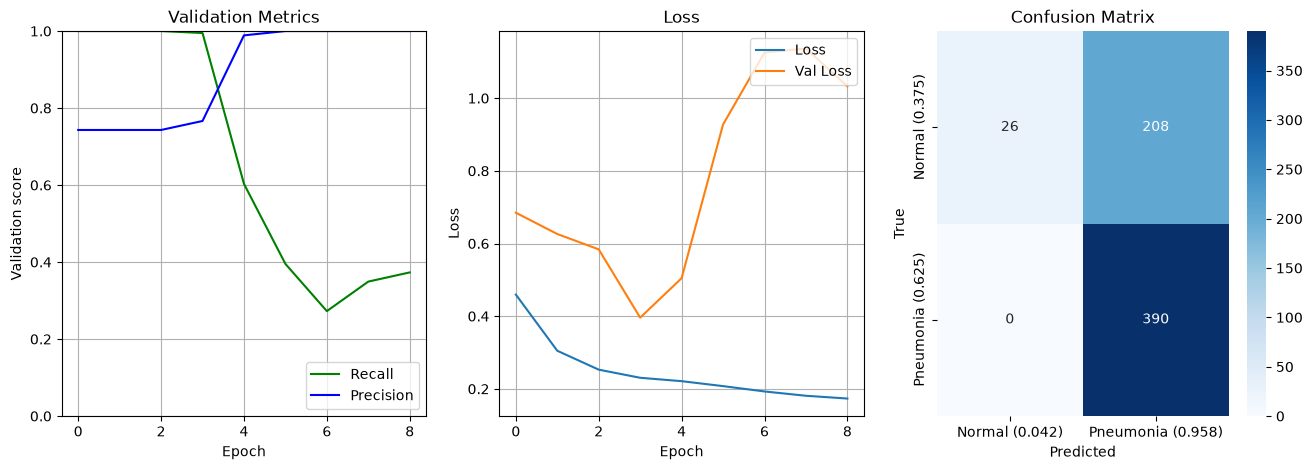

In [17]:
summary_graphics(history, model_4, test_ds)

In [18]:
reset_keras()

# add more convolutional layers and neurons to the dense layers
model_5 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="resizing"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="1.2batchnorm"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="1.3conv"
        ),
        tf.keras.layers.BatchNormalization(name="1.4batchnorm"),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            64, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="2.2batchnorm"),
        tf.keras.layers.Conv2D(
            64, (3, 3), activation="relu", padding="same", name="2.3conv"
        ),
        tf.keras.layers.BatchNormalization(name="2.4batchnorm"),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.5pool"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.4batchnorm"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="3.5conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.6batchnorm"),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.7pool"),
        tf.keras.layers.SeparableConv2D(
            256, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            256, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.4batchnorm"),
        tf.keras.layers.SeparableConv2D(
            256, (3, 3), activation="relu", padding="same", name="4.5conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.6batchnorm"),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.5pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(1024, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.7, name="5.3dropout"),
        tf.keras.layers.Dense(512, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.5, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_5",
)

model_5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/20


/home/sam/Documents/projects/ConvolutedComputerVision/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


139/139 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.6481 - loss: 0.4028 - precision: 0.8623 - recall: 0.6258 - tn: 961.0000 - tp: 2430.0000 - val_accuracy: 0.7430 - val_loss: 0.6822 - val_precision: 0.7430 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 587.0000 - learning_rate: 1.0000e-04
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 152ms/step - accuracy: 0.7618 - loss: 0.2829 - precision: 0.9011 - recall: 0.7627 - tn: 870.0000 - tp: 2514.0000 - val_accuracy: 0.7430 - val_loss: 0.6358 - val_precision: 0.7430 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 587.0000 - learning_rate: 1.0000e-04
Epoch 3/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - accuracy: 0.7850 - loss: 0.2451 - precision: 0.9126 - recall: 0.7855 - tn: 898.0000 - tp: 2589.0000 - val_accuracy: 0.7430 - val_loss: 0.5683 - val_precision: 0.7430 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 587.0000 - learning_rate: 1.0000e-04
Epoch 4/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.8071 - l

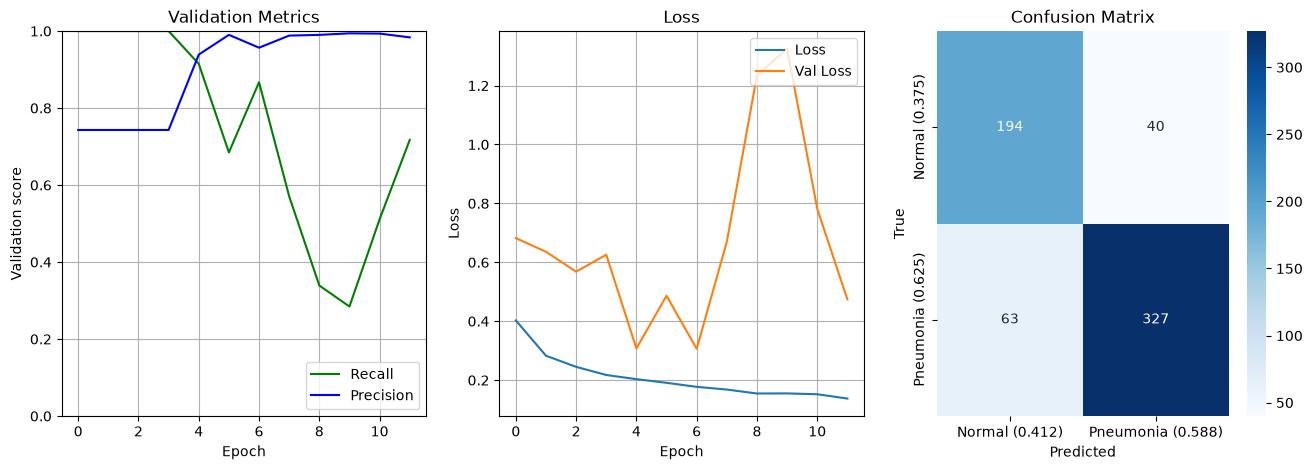

In [19]:
history = model_5.fit(
    train_ds,
    validation_data=validation_ds,
    batch_size=batch_size,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks("best_model_resizing_5.keras"),
)
summary_graphics(history, model_5, test_ds)

In [ ]:
notebook_end_time = datetime.datetime.now()
print(
    f"Notebook last run (end-to-end): {notebook_end_time} (duration: {notebook_end_time - notebook_start_time})"
)

Notebook last run (end-to-end): 2026-06-27 03:34:18.070402 (duration: 0:09:26.394293)


: 